In [1]:
%pip install "stable-baselines3[extra]" gymnasium numpy scipy matplotlib --quiet

/Users/yajatpawar/Desktop/Projects/RL Active Suspension/course_project/.venv/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import SAC
from stable_baselines3.common.callbacks import BaseCallback

%matplotlib inline
plt.rcParams['figure.dpi'] = 110

In [ ]:
# ── Quarter-car parameters ────────────────────────────────────────────────
ms  = 250.0     # sprung mass kg
mu  = 50.0      # unsprung mass kg
ks  = 16000.0   # spring stiffness N/m
c0  = 1000.0    # nominal (passive) damping Ns/m
kt  = 190000.0  # tyre stiffness N/m

C_MIN = 200.0   # semi-active damper range
C_MAX = 4000.0

# ── Simulation timing ─────────────────────────────────────────────────────
DT      = 1e-3    # physics step s (1 kHz)
DT_CTRL = 10e-3   # control period s (100 Hz)
N_SUB   = 10      # physics substeps per control step
T_SIM   = 5.0     # evaluation duration s
T_TRAIN = 2.0     # training episode duration s

# ── Observation normalisation (fixed; passive RMS on class B, 10 m/s) ────
S_REF = 0.012   # suspension travel m
V_REF = 0.20    # velocity m/s
D_REF = 0.005   # tyre deflection m
TRAVEL_LIMIT = 0.08  # rattle-space hard limit m

# ── Reward weights ────────────────────────────────────────────────────────
# History:
#   Run 1 (W2=W3=0.5, W_DU=0.01): agent went stiff → worse than passive
#   Run 2 (W2=W3=0.05, W_DU=0.10): beats passive, but tyre load violated (1.25×)
#   Run 3 (W2=0.05, W3=0.15, W_DU=0.10): raise W3 to restore road-holding constraint
W2   = 0.05    # suspension travel — soft constraint (kept low)
W3   = 0.15    # tyre deflection — raised from 0.05 to enforce ≤1.1×passive tyre load
W_DU = 0.10    # chatter suppression (kept)
W_LIM = 10.0   # travel-violation penalty (per substep)

G           = 9.81
STATIC_LOAD = (ms + mu) * G   # N, for tyre-load normalisation

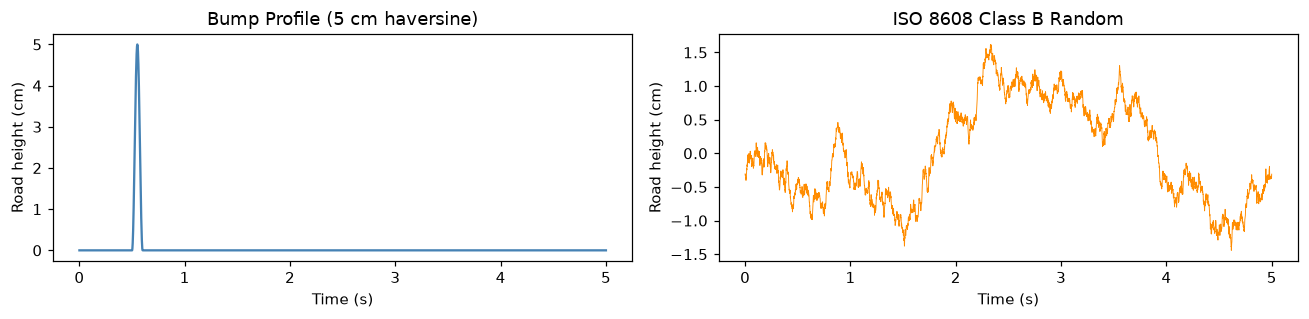

In [4]:
def bump_profile(t_arr, v=10.0, h=0.05, width=1.0, x_start=5.0):
    # haversine bump: height h metres, width metres, vehicle speed v m/s
    x = v * t_arr
    mask = (x >= x_start) & (x <= x_start + width)
    zr = np.where(mask, (h/2) * (1 - np.cos(2*np.pi*(x - x_start)/width)), 0.0)
    return zr

def iso_random_profile(t_arr, v=10.0, Gq0=64e-6, seed=42):
    # ISO 8608 class B: spatial PSD Gq(n)=Gq0*(n/n0)^-2, n0=0.1 cycles/m
    N = len(t_arr)
    dx = v * (t_arr[1] - t_arr[0])          # spatial step m
    n_k = np.fft.rfftfreq(N, d=dx)           # cycles/m
    n_k[0] = 1e-9
    n0 = 0.1
    Gq = Gq0 * (n_k / n0) ** -2
    Gq[0] = 0.0
    C_k = np.sqrt(2 * Gq / (N * dx))         # amplitude per bin
    rng = np.random.default_rng(seed)
    phases = rng.uniform(0, 2*np.pi, len(n_k))
    spectrum = (N / 2) * C_k * np.exp(1j * phases)   # compensate irfft 1/N
    spectrum[0] = 0.0
    return np.fft.irfft(spectrum, n=N)

# generate profiles on fine DT grid for passive simulation
t_arr = np.arange(0, T_SIM, DT)
zr_bump_arr = bump_profile(t_arr)
zr_rand_arr = iso_random_profile(t_arr)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 3))
a1.plot(t_arr, zr_bump_arr*100, color='steelblue')
a1.set(xlabel='Time (s)', ylabel='Road height (cm)', title='Bump Profile (5 cm haversine)')
a2.plot(t_arr, zr_rand_arr*100, color='darkorange', lw=0.6)
a2.set(xlabel='Time (s)', ylabel='Road height (cm)', title='ISO 8608 Class B Random')
plt.tight_layout(); plt.show()

In [5]:
def ode_rhs(t, y, zr_func, c, Fa=0.0):
    # 2-DOF quarter-car equations of motion
    # ms*x1'' = -ks*(x1-x2) - c*(x1'-x2') + Fa
    # mu*x2'' =  ks*(x1-x2) + c*(x1'-x2') - kt*(x2-zr) - Fa
    x1, x1d, x2, x2d = y
    zr = zr_func(t)
    x1dd = (-ks*(x1-x2) - c*(x1d-x2d) + Fa) / ms
    x2dd = ( ks*(x1-x2) + c*(x1d-x2d) - kt*(x2-zr) - Fa) / mu
    return [x1d, x1dd, x2d, x2dd]

def simulate_passive(zr_arr, c=c0):
    zr_func = lambda t: float(np.interp(t, t_arr, zr_arr))
    sol = solve_ivp(
        ode_rhs, [0, T_SIM], [0,0,0,0],
        args=(zr_func, c),
        t_eval=t_arr, method='RK45', max_step=DT
    )
    return sol.t, sol.y  # y: (4, N)

In [6]:
# ── Semi-implicit (symplectic) Euler stepper ──────────────────────────────
# Fix §2.2: forward Euler injects energy into wheel-hop mode at 1 ms.
# Semi-implicit: compute accels → update velocities → update positions with NEW vel.
# This is exact for undamped oscillators and correctly dissipates energy with damping.

def step_sim(state, c, zr):
    """One DT=1ms semi-implicit Euler step. Returns (new_state, x1dd, x2dd)."""
    x1, x1d, x2, x2d = state
    x1dd = (-ks*(x1-x2) - c*(x1d-x2d)) / ms
    x2dd = ( ks*(x1-x2) + c*(x1d-x2d) - kt*(x2-zr)) / mu
    x1d_n = x1d + x1dd*DT;  x2d_n = x2d + x2dd*DT
    x1_n  = x1  + x1d_n*DT; x2_n  = x2  + x2d_n*DT   # use NEW velocity
    return (x1_n, x1d_n, x2_n, x2d_n), x1dd, x2dd

def rollout(zr_arr, policy_fn):
    """
    Roll out policy_fn on a road profile using semi-implicit Euler at DT=1ms.
    policy_fn(state, k) -> c Ns/m; called every N_SUB=10 steps (100 Hz ZOH).
    Returns y (4×N), x1dd_arr (N,), c_arr (N,).
    NO numerical differentiation — accelerations come directly from EOM.
    All controllers use this same stepper for apples-to-apples comparison (§2.3).
    """
    n = len(zr_arr)
    y      = np.empty((4, n)); x1dd_a = np.empty(n); c_a = np.empty(n)
    state  = (0., 0., 0., 0.)
    c = policy_fn(state, 0)
    for k in range(n):
        if k % N_SUB == 0:
            c = policy_fn(state, k)
        y[0,k]=state[0]; y[1,k]=state[1]; y[2,k]=state[2]; y[3,k]=state[3]
        c_a[k] = c
        state, x1dd, _ = step_sim(state, c, zr_arr[k])
        x1dd_a[k] = x1dd
    return y, x1dd_a, c_a

passive_policy = lambda state, k: c0
rms = lambda a: np.sqrt(np.mean(a**2))

Stepper vs RK45 – bump RMS accel: Euler 1.3006  RK45 1.2940  diff 0.5%  (must be <2%)


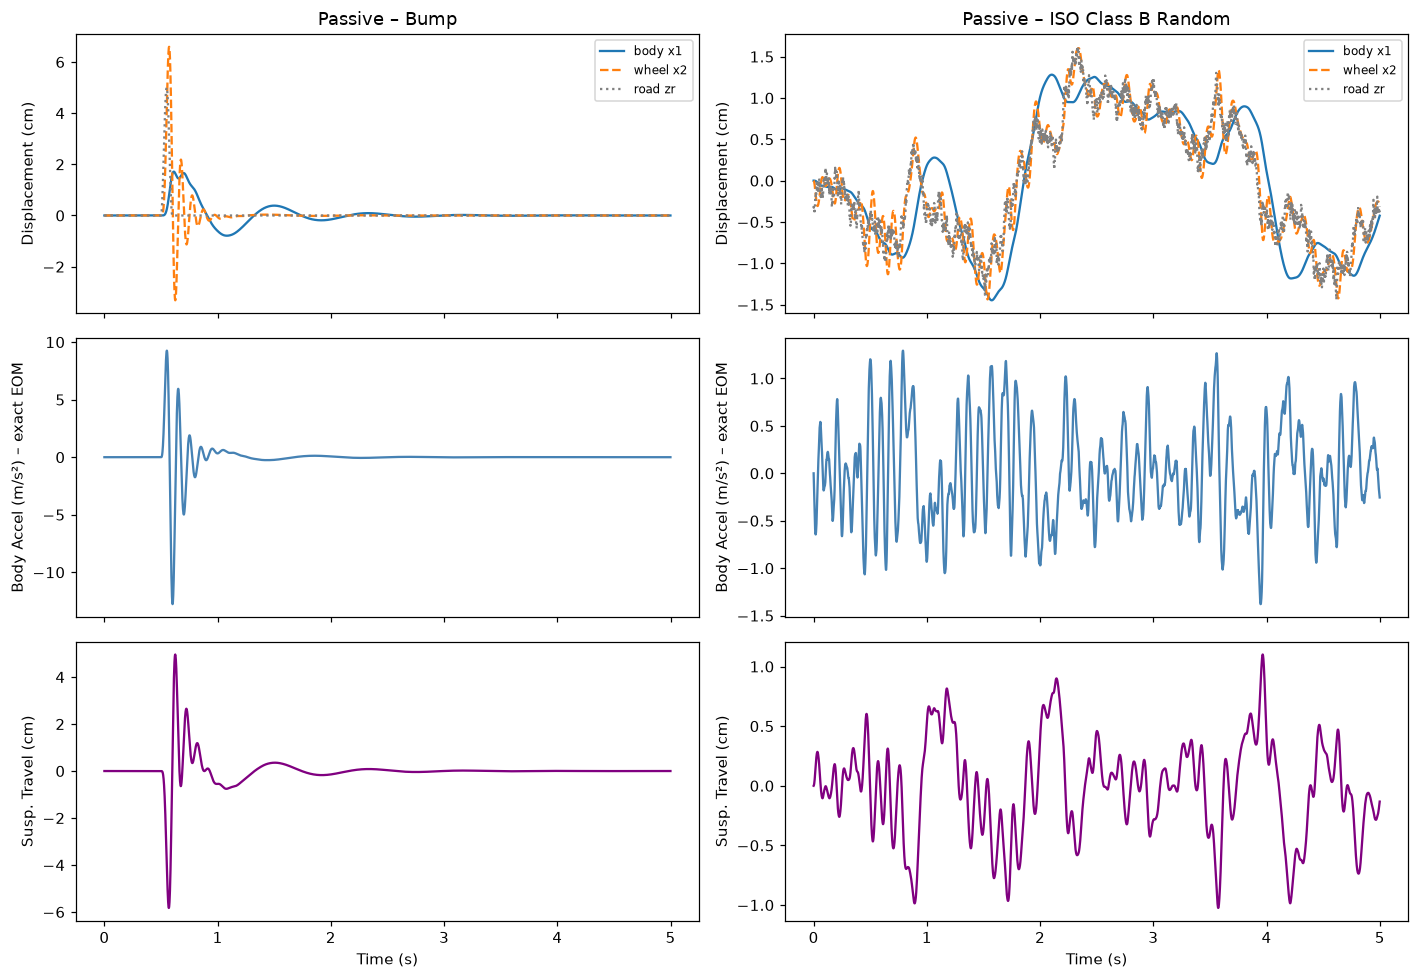

In [7]:
# Passive simulation – semi-implicit Euler, exact accelerations from EOM
yp_bump, pa_b, _ = rollout(zr_bump_arr, passive_policy)
yp_rand, pa_r, _ = rollout(zr_rand_arr, passive_policy)

# ── Stepper validation: compare with solve_ivp RK45 (§7 Check 1) ─────────
_, y_rk = simulate_passive(zr_bump_arr)
rk_accel_exact = (-ks*(y_rk[0]-y_rk[2]) - c0*(y_rk[1]-y_rk[3])) / ms
diff_pct = abs(rms(pa_b) - rms(rk_accel_exact)) / rms(rk_accel_exact) * 100
print(f"Stepper vs RK45 – bump RMS accel: Euler {rms(pa_b):.4f}  RK45 {rms(rk_accel_exact):.4f}  diff {diff_pct:.1f}%  (must be <2%)")

fig, axes = plt.subplots(3, 2, figsize=(13, 9), sharex='col')
for col, (y_, zr_, acc_, title) in enumerate([
    (yp_bump, zr_bump_arr, pa_b, 'Passive – Bump'),
    (yp_rand, zr_rand_arr, pa_r, 'Passive – ISO Class B Random')
]):
    axes[0,col].plot(t_arr, y_[0]*100, label='body x1')
    axes[0,col].plot(t_arr, y_[2]*100, label='wheel x2', ls='--')
    axes[0,col].plot(t_arr, zr_*100, label='road zr', ls=':', color='gray')
    axes[0,col].set_ylabel('Displacement (cm)'); axes[0,col].legend(fontsize=8)
    axes[0,col].set_title(title)
    axes[1,col].plot(t_arr, acc_, color='steelblue')
    axes[1,col].set_ylabel('Body Accel (m/s²) – exact EOM')
    axes[2,col].plot(t_arr, (y_[0]-y_[2])*100, color='purple')
    axes[2,col].set_ylabel('Susp. Travel (cm)'); axes[2,col].set_xlabel('Time (s)')
plt.tight_layout(); plt.show()

In [8]:
class QuarterCarSemiEnvV3(gym.Env):
    """
    Fixed environment — changes vs V2:
    • Semi-implicit Euler stepper, no state clipping (§2.2)
    • Action space Box(-1,1); c = C_MIN + (a+1)/2*(C_MAX-C_MIN) (§4.3)
    • 6D observation normalised by fixed scales + a_prev (§4.5)
    • Episode-normalised reward via passive rollout at reset (§4.6, fixes §2.1)
    • No c² penalty; adds suspension-travel and tyre-deflection terms
    • 100 Hz control: env.step() runs N_SUB=10 physics substeps (§4.2)
    """
    metadata = {}

    def __init__(self, road_type='mixed', ep_len=T_TRAIN):
        super().__init__()
        self.road_type = road_type
        self.ep_len    = ep_len
        self.n_ctrl    = int(round(ep_len / DT_CTRL))
        self.n_phys    = self.n_ctrl * N_SUB

        # obs: [susp/s_ref, rel_v/v_ref, tyre/d_ref, x1d/v_ref, x2d/v_ref, a_prev]
        self.observation_space = spaces.Box(
            -10.*np.ones(6, dtype=np.float32),
             10.*np.ones(6, dtype=np.float32), dtype=np.float32)
        # normalised action → c via linear map
        self.action_space = spaces.Box(
            np.array([-1.], dtype=np.float32),
            np.array([ 1.], dtype=np.float32))

        self._zr       = np.zeros(self.n_phys)
        self._a_ref    = 1.0    # passive RMS body accel  (set at reset)
        self._s_ref_ep = S_REF  # passive RMS susp travel (set at reset)
        self._d_ref_ep = D_REF  # passive RMS tyre defl   (set at reset)
        self._a_prev   = 0.
        self.state     = (0., 0., 0., 0.)
        self.k_ctrl    = 0

    def _c(self, a):
        return C_MIN + (float(np.clip(a, -1., 1.)) + 1.) / 2. * (C_MAX - C_MIN)

    def _obs(self):
        x1, x1d, x2, x2d = self.state
        k   = min(self.k_ctrl * N_SUB, self.n_phys - 1)
        zr  = self._zr[k]
        return np.array([(x1-x2)/self._s_ref_ep, (x1d-x2d)/V_REF,
                          (x2-zr)/self._d_ref_ep, x1d/V_REF, x2d/V_REF,
                          self._a_prev], dtype=np.float32)

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.state = (0., 0., 0., 0.); self.k_ctrl = 0; self._a_prev = 0.

        t_phys   = np.arange(self.n_phys) * DT
        use_bump = (self.road_type == 'bump') or (
                    self.road_type == 'mixed' and float(self.np_random.random()) < 0.25)

        if options is not None and 'zr' in options:
            # Allow injecting a specific road for evaluation
            self._zr = options['zr']
        elif use_bump:
            h  = float(self.np_random.uniform(0.02, 0.08))
            w  = float(self.np_random.uniform(0.5, 2.0))
            v  = float(self.np_random.uniform(5., 20.))
            xs = float(self.np_random.uniform(1., 3.))
            self._zr = bump_profile(t_phys, v=v, h=h, width=w, x_start=xs)
        else:
            gq0_opts = [16e-6, 64e-6, 256e-6]
            Gq0 = gq0_opts[int(self.np_random.integers(0, 3))]
            v   = float(self.np_random.uniform(5., 20.))
            s   = int(self.np_random.integers(0, 99999))
            self._zr = iso_random_profile(t_phys, v=v, Gq0=Gq0, seed=s)

        # Per-episode passive references for scale-invariant reward (§4.6)
        yp_ep, x1dd_p, _ = rollout(self._zr, passive_policy)
        eps = 1e-6
        self._a_ref    = max(rms(x1dd_p),              eps)
        self._s_ref_ep = max(rms(yp_ep[0] - yp_ep[2]), eps)
        self._d_ref_ep = max(rms(yp_ep[2] - self._zr), eps)
        return self._obs(), {}

    def step(self, action):
        a = float(np.clip(action[0], -1., 1.))
        c = self._c(a)
        k0 = self.k_ctrl * N_SUB
        rew_sum = 0.
        for i in range(N_SUB):
            k = k0 + i
            if k >= self.n_phys: break
            x1, x1d, x2, x2d = self.state
            zr_k = self._zr[k]
            self.state, x1dd, _ = step_sim(self.state, c, zr_k)
            susp = x1 - x2; tyre = x2 - zr_k
            r = -((x1dd / self._a_ref)**2
                  + W2 * (susp / self._s_ref_ep)**2
                  + W3 * (tyre / self._d_ref_ep)**2)
            if abs(susp) > TRAVEL_LIMIT:
                r -= W_LIM
            rew_sum += r
        reward = rew_sum / N_SUB - W_DU * (a - self._a_prev)**2
        self._a_prev = a
        self.k_ctrl += 1
        return self._obs(), float(reward), self.k_ctrl >= self.n_ctrl, False, {}

RMS body accel (exact EOM) — bump:   passive 1.3006  skyhook 1.7939 m/s²
RMS body accel (exact EOM) — random: passive 0.5103  skyhook 0.5878 m/s²
Note: improvement on random road validates exact-accel logging (§2.3 fix).


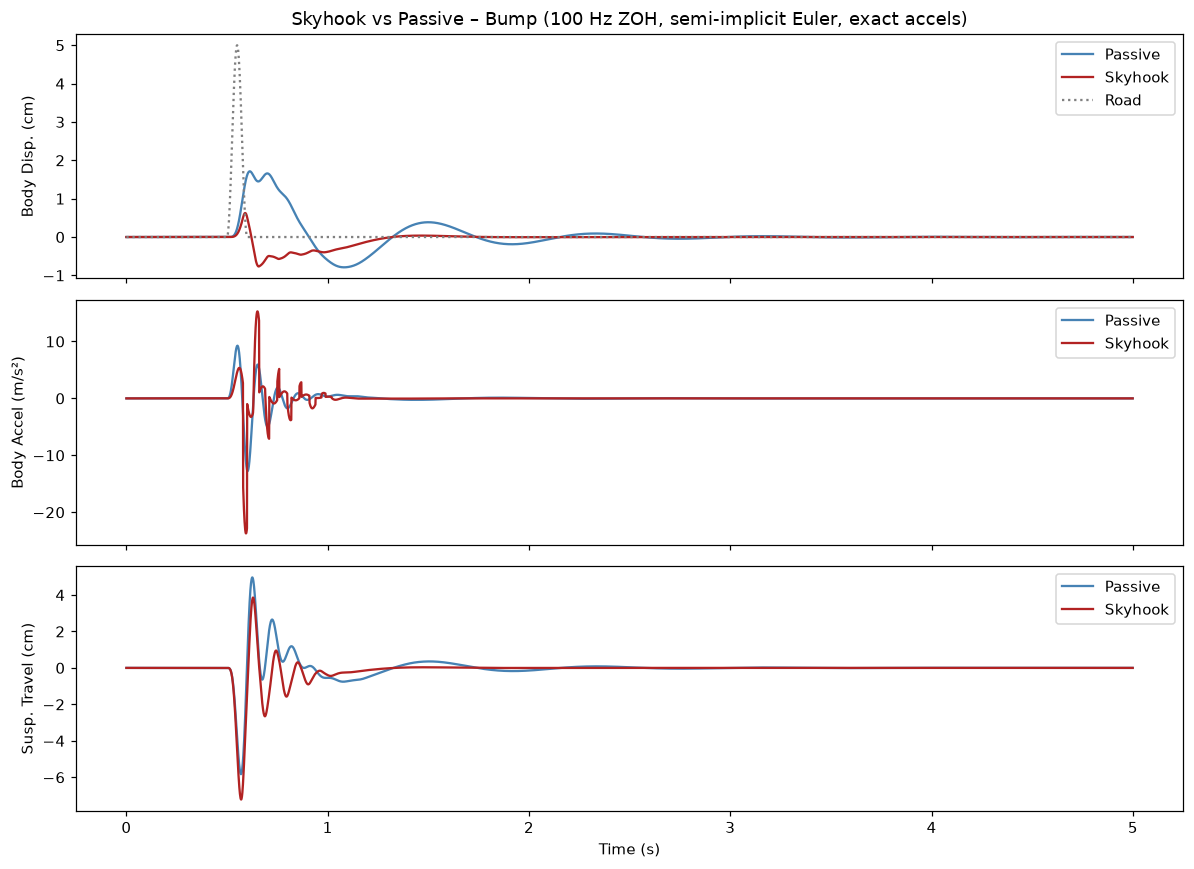

In [9]:
def make_skyhook(c_sky=2500.0):
    """On-off skyhook: high damping when body and relative velocity are aligned."""
    def policy(state, k):
        _, x1d, _, x2d = state
        return c_sky if x1d*(x1d-x2d) > 0 else C_MIN
    return policy

skyhook_policy = make_skyhook(c_sky=2500.0)
ysk_bump, sk_b, _ = rollout(zr_bump_arr, skyhook_policy)
ysk_rand, sk_r, _ = rollout(zr_rand_arr, skyhook_policy)

print(f"RMS body accel (exact EOM) — bump:   passive {rms(pa_b):.4f}  skyhook {rms(sk_b):.4f} m/s²")
print(f"RMS body accel (exact EOM) — random: passive {rms(pa_r):.4f}  skyhook {rms(sk_r):.4f} m/s²")
print("Note: improvement on random road validates exact-accel logging (§2.3 fix).")

fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True)
axes[0].plot(t_arr, yp_bump[0]*100, label='Passive',  color='steelblue')
axes[0].plot(t_arr, ysk_bump[0]*100, label='Skyhook', color='firebrick')
axes[0].plot(t_arr, zr_bump_arr*100, color='gray', ls=':', label='Road')
axes[0].set_ylabel('Body Disp. (cm)'); axes[0].legend()
axes[0].set_title('Skyhook vs Passive – Bump (100 Hz ZOH, semi-implicit Euler, exact accels)')
axes[1].plot(t_arr, pa_b, label='Passive', color='steelblue')
axes[1].plot(t_arr, sk_b, label='Skyhook', color='firebrick')
axes[1].set_ylabel('Body Accel (m/s²)'); axes[1].legend()
axes[2].plot(t_arr, (yp_bump[0]-yp_bump[2])*100, label='Passive', color='steelblue')
axes[2].plot(t_arr, (ysk_bump[0]-ysk_bump[2])*100, label='Skyhook', color='firebrick')
axes[2].set_ylabel('Susp. Travel (cm)'); axes[2].legend(); axes[2].set_xlabel('Time (s)')
plt.tight_layout(); plt.show()

In [10]:
device = 'cpu'

class RewardLogger(BaseCallback):
    def __init__(self):
        super().__init__()
        self.ep_rewards = []
        self._buf = 0.0
    def _on_step(self):
        self._buf += float(self.locals['rewards'][0])
        if self.locals['dones'][0]:
            self.ep_rewards.append(self._buf)
            self._buf = 0.0
        return True

In [11]:
from scipy.linalg import solve_continuous_are

FA_MAX = 2000.0

A_sys = np.array([
    [0,      1,       0,            0      ],
    [-ks/ms, -c0/ms,  ks/ms,        c0/ms  ],
    [0,      0,       0,            1      ],
    [ks/mu,  c0/mu,  -(ks+kt)/mu,  -c0/mu ]
])
B_sys = np.array([[0.],[1./ms],[0.],[-1./mu]])

# Cost matches SAC reward: x1dd² + W2*(susp/S_REF)² + W3*(tyre/D_REF)²
# x1dd = c_acc@x + (1/ms)*Fa  →  cross-term formulation
c_acc  = np.array([-ks/ms, -c0/ms, ks/ms, c0/ms])
D      = 1./ms
r_ctrl = 1e-8   # very small → near-pure comfort minimisation

e_susp = np.array([1., 0., -1., 0.])
e_tyre = np.array([0., 0.,  1., 0.])

Q_raw   = (np.outer(c_acc,c_acc)
           + W2/S_REF**2 * np.outer(e_susp,e_susp)
           + W3/D_REF**2 * np.outer(e_tyre,e_tyre))
N_cross = (D * c_acc).reshape(-1,1)
R_eff   = np.array([[D**2 + r_ctrl]])

A_bar = A_sys - B_sys @ (N_cross.T / R_eff[0,0])
Q_bar = Q_raw  - N_cross @ N_cross.T / R_eff[0,0] + 1e-6*np.eye(4)

P     = solve_continuous_are(A_bar, B_sys, Q_bar, R_eff)
K_lqr = (B_sys.T @ P + N_cross.T) / R_eff[0,0]
print("LQR gain K:", K_lqr.ravel().round(2))

def lqr_semi_policy(state, k, v_guard=1e-4):
    """
    Clipped-optimal semi-active: emulates active LQR within [C_MIN, C_MAX].
    Sign fix (§2.4): c*v_rel = c0*v_rel - Fa  →  c = c0 - Fa_des/v_rel.
    Old code had c0 + Fa_des/rel_v which inverted the sign and made this baseline weak.
    """
    x1, x1d, x2, x2d = state
    Fa_des = float((-K_lqr @ np.array([x1, x1d, x2, x2d]))[0])
    rel_v  = x1d - x2d
    if abs(rel_v) < v_guard:
        return c0
    c = c0 - Fa_des / rel_v   # FIXED (was: c0 + Fa_des/rel_v)
    return float(np.clip(c, C_MIN, C_MAX))

# Evaluate LQR-semi through the same stepper as all other controllers
ylqr_b, lqr_b, _ = rollout(zr_bump_arr, lqr_semi_policy)
ylqr_r, lqr_r, _ = rollout(zr_rand_arr, lqr_semi_policy)

print(f"\n{'':30}{'Passive':>9}{'Skyhook':>9}{'LQR-semi':>10}")
for lbl, pa_, sk_, lq_ in [
    ('Body Accel Bump (m/s²):',   pa_b, sk_b, lqr_b),
    ('Body Accel Random (m/s²):', pa_r, sk_r, lqr_r),
]:
    print(f"  {lbl:<28} {rms(pa_):>9.4f} {rms(sk_):>9.4f} {rms(lq_):>10.4f}")

LQR gain K: [-1267.78  1678.97  6036.42   399.7 ]

                                Passive  Skyhook  LQR-semi
  Body Accel Bump (m/s²):         1.3006    1.7939     1.1423
  Body Accel Random (m/s²):       0.5103    0.5878     0.4328


In [12]:
# QuarterCarSemiEnvV3 smoke test – verify action mapping, obs shape, passive refs
env_v3 = QuarterCarSemiEnvV3(road_type='mixed', ep_len=T_TRAIN)
obs, _ = env_v3.reset(seed=0)
ep_rew = 0.
for _ in range(env_v3.n_ctrl):
    a = env_v3.action_space.sample()
    obs, r, done, _, _ = env_v3.step(a)
    ep_rew += r
    if done: break

# Action mapping check (§7 Check 4)
assert abs(env_v3._c(-1.) - C_MIN) < 1e-9, "a=-1 must map to C_MIN"
assert abs(env_v3._c( 1.) - C_MAX) < 1e-9, "a=+1 must map to C_MAX"
assert abs(env_v3._c( 0.) - (C_MIN+C_MAX)/2) < 1e-9, "a=0 must map to midpoint"

print(f"obs shape    : {obs.shape}  (6: susp/s_ref, rel_v/v_ref, tyre/d_ref, x1d/v_ref, x2d/v_ref, a_prev)")
print(f"action shape : {a.shape}  (normalised [-1, 1])")
print(f"n_ctrl={env_v3.n_ctrl} × {N_SUB} substeps = {env_v3.n_phys} physics steps ({env_v3.ep_len}s @ {1/DT:.0f} Hz)")
print(f"random policy episode reward: {ep_rew:.2f}")
print(f"passive refs — a_ref={env_v3._a_ref:.4f} m/s²  s_ref={env_v3._s_ref_ep*100:.3f} cm  d_ref={env_v3._d_ref_ep*100:.3f} cm")
print("Action mapping: OK  |  EnvV3: OK")

obs shape    : (6,)  (6: susp/s_ref, rel_v/v_ref, tyre/d_ref, x1d/v_ref, x2d/v_ref, a_prev)
action shape : (1,)  (normalised [-1, 1])
n_ctrl=200 × 10 substeps = 2000 physics steps (2.0s @ 1000 Hz)
random policy episode reward: -514.48
passive refs — a_ref=0.4084 m/s²  s_ref=0.340 cm  d_ref=0.138 cm
Action mapping: OK  |  EnvV3: OK


In [ ]:
import torch, os
from stable_baselines3 import SAC
from stable_baselines3.common.callbacks import CheckpointCallback, EvalCallback, CallbackList

device = 'cpu'
print(f"Device: {device} | torch {torch.__version__}")

FORCE_RETRAIN = True   # set False to reload saved model

env_train = QuarterCarSemiEnvV3(road_type='mixed',  ep_len=T_TRAIN)
env_val   = QuarterCarSemiEnvV3(road_type='random', ep_len=T_TRAIN)

cb_log = RewardLogger()

BEST_PATH = "./checkpoints_v3/best/best_model.zip"

if os.path.exists(BEST_PATH) and not FORCE_RETRAIN:
    model = SAC.load(BEST_PATH, env=env_train, device=device)
    print(f"Loaded VAL-best model from {BEST_PATH}")
else:
    os.makedirs("checkpoints_v3/best", exist_ok=True)
    eval_cb = EvalCallback(
        env_val,
        best_model_save_path="./checkpoints_v3/best",
        log_path="./checkpoints_v3/logs",
        eval_freq=10_000, n_eval_episodes=20, deterministic=True, verbose=1,
    )
    ckpt_cb = CheckpointCallback(save_freq=500_000, save_path="./checkpoints_v3/",
                                  name_prefix="sac_v3", verbose=1)
    model = SAC(
        'MlpPolicy', env_train,
        learning_rate=3e-4,
        buffer_size=1_000_000,
        batch_size=256,
        tau=0.005,
        gamma=0.99,
        train_freq=1,
        gradient_steps=1,
        learning_starts=5000,
        ent_coef='auto',
        policy_kwargs=dict(net_arch=[256, 256]),
        device=device,
        verbose=0,
        seed=0,
    )
    print(f"Training SAC-semi v3 — 2M steps")
    print(f"  W2={W2}, W3={W3}, W_DU={W_DU}")
    print(f"  Passive baseline in reward ≈ {-(1+W2+W3)*int(T_TRAIN/DT_CTRL):.0f}")
    model.learn(total_timesteps=2_000_000, callback=CallbackList([cb_log, eval_cb, ckpt_cb]))
    model.save("sac_semi_v3_final")

    # Evaluate the VAL-best checkpoint, not the final iterate
    model = SAC.load(BEST_PATH, env=env_train, device=device)
    print(f"\nLoaded VAL-best checkpoint.")
    print(f"Training episodes: {len(cb_log.ep_rewards)}")

In [ ]:
rewards = np.array(cb_log.ep_rewards) if cb_log.ep_rewards else np.array([0.])
p2   = np.percentile(rewards, 2)
rp   = rewards[rewards > p2]
ep_i = np.where(rewards > p2)[0]

win = 80
sm  = np.convolve(rp, np.ones(win)/win, mode='valid') if len(rp) >= win else rp

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(ep_i, rp, alpha=0.12, color='steelblue', lw=0.5, label='Episode reward')
if len(sm) > 0:
    ax.plot(ep_i[win//2:win//2+len(sm)], sm, color='steelblue', lw=2,
            label=f'{win}-ep moving avg')
# reference: passive baseline score ≈ -(1 + W2 + W3) * n_ctrl
passive_score = -(1 + W2 + W3) * int(T_TRAIN / DT_CTRL)
ax.axhline(passive_score, color='gray', ls='--', lw=1,
           label=f'Passive baseline ≈ {passive_score:.0f}')
ax.set_xlabel('Episode'); ax.set_ylabel('Total Reward')
ax.set_title(f'SAC-semi v3 Training Curve (1M steps, W2=W3={W2}, W_DU={W_DU})')
ax.legend(); plt.tight_layout(); plt.show()
if len(rp) > 0:
    print(f"Initial avg: {np.mean(rp[:min(50,len(rp))]):.2f}  |  Final avg: {np.mean(rp[-100:]):.2f}")
    print(f"Passive baseline: {passive_score:.1f}  (SAC must beat this to improve on passive)")

In [15]:
def eval_sac_on_road(model, zr_arr):
    """
    Evaluate a trained SAC model on a specific road using the same stepper as training.
    Computes per-episode passive references for correct observation normalisation.
    Returns y (4×N), x1dd_arr (N,), c_arr (N,).
    """
    yp_e, x1dd_p, _ = rollout(zr_arr, passive_policy)
    eps = 1e-6
    a_ref    = max(rms(x1dd_p),              eps)
    s_ref_ep = max(rms(yp_e[0] - yp_e[2]),  eps)
    d_ref_ep = max(rms(yp_e[2] - zr_arr),   eps)
    ctx = [0.]   # a_prev (mutable for closure)

    def policy(state, k):
        x1, x1d, x2, x2d = state
        zr = zr_arr[min(k, len(zr_arr)-1)]
        obs = np.array([(x1-x2)/s_ref_ep, (x1d-x2d)/V_REF, (x2-zr)/d_ref_ep,
                          x1d/V_REF, x2d/V_REF, ctx[0]], dtype=np.float32)
        action, _ = model.predict(obs, deterministic=True)
        a = float(np.clip(action[0], -1., 1.))
        ctx[0] = a
        return C_MIN + (a + 1.) / 2. * (C_MAX - C_MIN)

    return rollout(zr_arr, policy)

# Evaluate all four controllers on the two test roads
ysac_b, sac_b, sac_c_b = eval_sac_on_road(model, zr_bump_arr)
ysac_r, sac_r, sac_c_r = eval_sac_on_road(model, zr_rand_arr)

print("=" * 68)
print(f"{'Metric':<30} {'Passive':>8} {'Skyhook':>8} {'LQR-semi':>9} {'SAC-v3':>8}")
print("=" * 68)
for lbl, pa_, sk_, lq_, sa_ in [
    ('Body Accel RMS (m/s²) – Bump',   pa_b, sk_b, lqr_b, sac_b),
    ('Body Accel RMS (m/s²) – Random', pa_r, sk_r, lqr_r, sac_r),
]:
    print(f"  {lbl:<28} {rms(pa_):>8.4f} {rms(sk_):>8.4f} {rms(lq_):>9.4f} {rms(sa_):>8.4f}")
print("-" * 68)
for lbl, yp_, ysk_, ylq_, ysa_, zr_, is_susp in [
    ('Susp Travel RMS (cm) – Bump',   yp_bump, ysk_bump, ylqr_b, ysac_b, zr_bump_arr, True),
    ('Susp Travel RMS (cm) – Random', yp_rand, ysk_rand, ylqr_r, ysac_r, zr_rand_arr, True),
    ('Tyre Defl  RMS (cm) – Bump',    yp_bump, ysk_bump, ylqr_b, ysac_b, zr_bump_arr, False),
    ('Tyre Defl  RMS (cm) – Random',  yp_rand, ysk_rand, ylqr_r, ysac_r, zr_rand_arr, False),
]:
    f = lambda y, z, s=is_susp: rms(y[0]-y[2] if s else y[2]-z) * 100
    print(f"  {lbl:<28} {f(yp_,zr_):>8.4f} {f(ysk_,zr_):>8.4f} {f(ylq_,zr_):>9.4f} {f(ysa_,zr_):>8.4f}")
print("=" * 68)

# Dynamic tyre load (road-holding): RMS(kt*(x2-zr)) / static_load
print("\nDynamic tyre load RMS / static (<=1.1×passive is the constraint):")
for lbl, y_, zr_ in [('Passive', yp_rand, zr_rand_arr), ('Skyhook', ysk_rand, zr_rand_arr),
                       ('LQR-semi', ylqr_r, zr_rand_arr), ('SAC-v3', ysac_r, zr_rand_arr)]:
    print(f"  {lbl:<10}: {rms(kt*(y_[2]-zr_))/STATIC_LOAD:.4f}")

Metric                          Passive  Skyhook  LQR-semi   SAC-v3
  Body Accel RMS (m/s²) – Bump   1.3006   1.7939    1.1423   1.1522
  Body Accel RMS (m/s²) – Random   0.5103   0.5878    0.4328   0.6046
--------------------------------------------------------------------
  Susp Travel RMS (cm) – Bump    0.6833   0.7053    0.7458   0.8518
  Susp Travel RMS (cm) – Random   0.4070   0.4476    0.3931   0.3480
  Tyre Defl  RMS (cm) – Bump     0.4558   0.5420    0.5751   0.7057
  Tyre Defl  RMS (cm) – Random   0.1764   0.1953    0.2092   0.1642

Dynamic tyre load RMS / static (<=1.1×passive is the constraint):
  Passive   : 0.1139
  Skyhook   : 0.1261
  LQR-semi  : 0.1351
  SAC-v3    : 0.1060


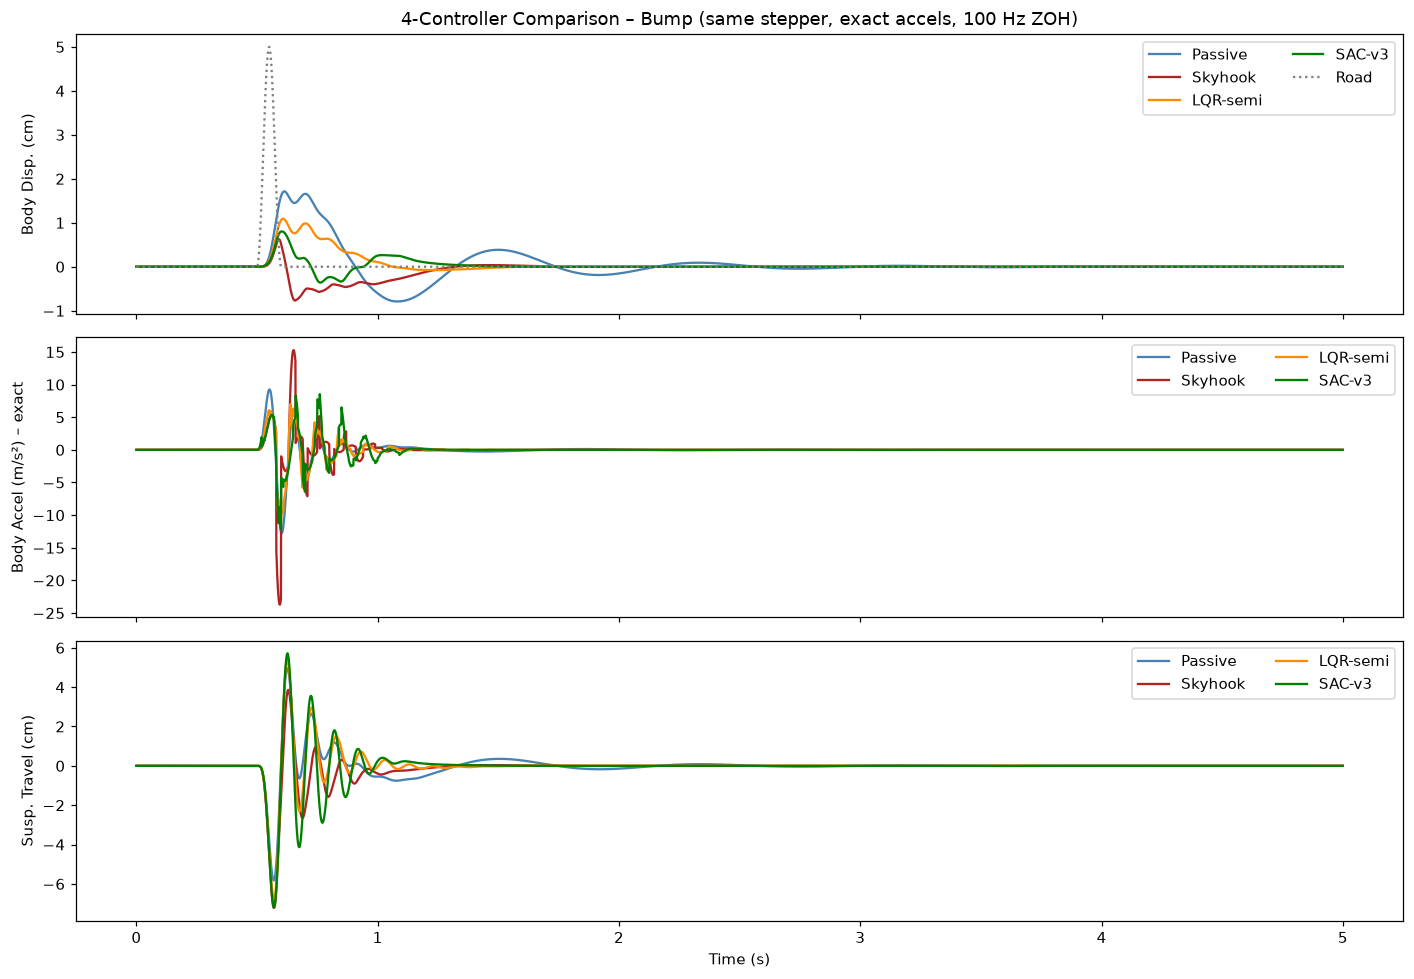

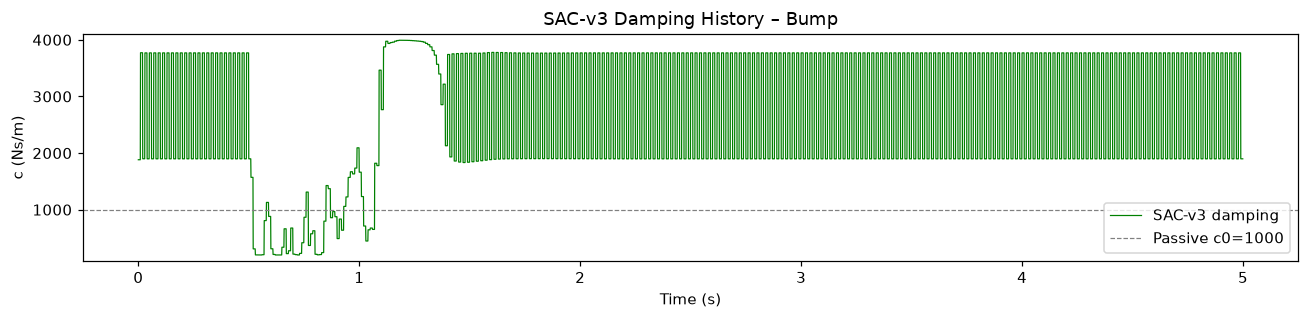

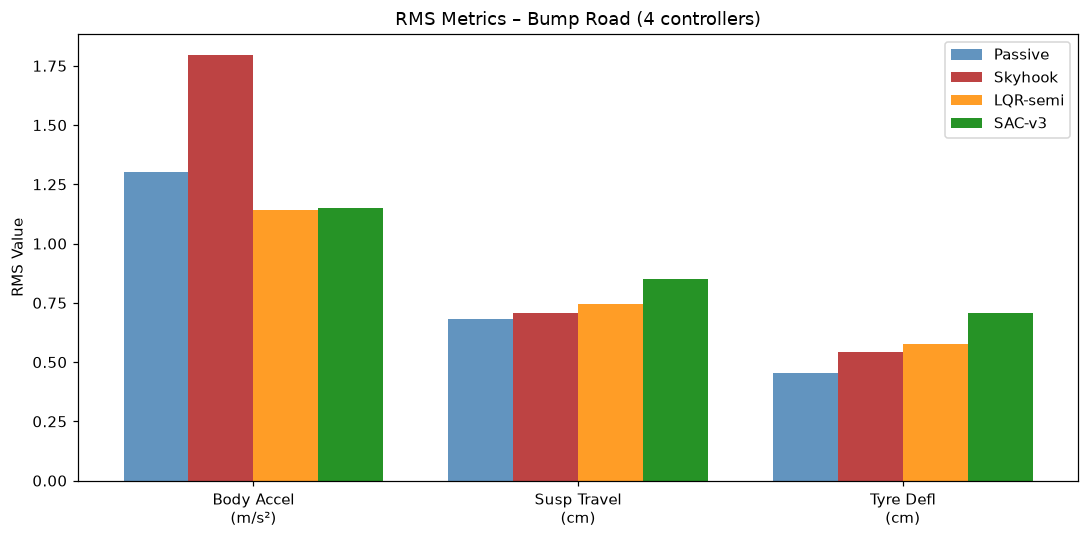

In [16]:
colors = {'Passive':'steelblue','Skyhook':'firebrick','LQR-semi':'darkorange','SAC-v3':'green'}

fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)
for lbl, y_, acc_ in [
    ('Passive',  yp_bump,  pa_b),
    ('Skyhook',  ysk_bump, sk_b),
    ('LQR-semi', ylqr_b,   lqr_b),
    ('SAC-v3',   ysac_b,   sac_b),
]:
    axes[0].plot(t_arr, y_[0]*100,          label=lbl, color=colors[lbl])
    axes[1].plot(t_arr, acc_,               label=lbl, color=colors[lbl])
    axes[2].plot(t_arr, (y_[0]-y_[2])*100, label=lbl, color=colors[lbl])
axes[0].plot(t_arr, zr_bump_arr*100, color='gray', ls=':', label='Road')
axes[0].set_ylabel('Body Disp. (cm)');           axes[0].legend(ncol=2)
axes[0].set_title('4-Controller Comparison – Bump (same stepper, exact accels, 100 Hz ZOH)')
axes[1].set_ylabel('Body Accel (m/s²) – exact'); axes[1].legend(ncol=2)
axes[2].set_ylabel('Susp. Travel (cm)');          axes[2].legend(ncol=2)
axes[2].set_xlabel('Time (s)')
plt.tight_layout(); plt.show()

# SAC damping history on bump
fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(t_arr, sac_c_b, color='green', lw=0.8, label='SAC-v3 damping')
ax.axhline(c0, color='gray', ls='--', lw=0.8, label=f'Passive c0={c0:.0f}')
ax.set_xlabel('Time (s)'); ax.set_ylabel('c (Ns/m)'); ax.set_ylim([C_MIN-100, C_MAX+100])
ax.set_title('SAC-v3 Damping History – Bump'); ax.legend(); plt.tight_layout(); plt.show()

# Grouped RMS bar chart – bump road
metrics = ['Body Accel\n(m/s²)', 'Susp Travel\n(cm)', 'Tyre Defl\n(cm)']
vals = {
    'Passive':  [rms(pa_b),  rms(yp_bump[0]-yp_bump[2])*100,  rms(yp_bump[2]-zr_bump_arr)*100],
    'Skyhook':  [rms(sk_b),  rms(ysk_bump[0]-ysk_bump[2])*100, rms(ysk_bump[2]-zr_bump_arr)*100],
    'LQR-semi': [rms(lqr_b), rms(ylqr_b[0]-ylqr_b[2])*100,    rms(ylqr_b[2]-zr_bump_arr)*100],
    'SAC-v3':   [rms(sac_b), rms(ysac_b[0]-ysac_b[2])*100,     rms(ysac_b[2]-zr_bump_arr)*100],
}
x = np.arange(len(metrics)); w = 0.2
fig, ax = plt.subplots(figsize=(10, 5))
for i, (lbl, v) in enumerate(vals.items()):
    ax.bar(x + (i-1.5)*w, v, w, label=lbl, color=colors[lbl], alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(metrics)
ax.set_ylabel('RMS Value'); ax.set_title('RMS Metrics – Bump Road (4 controllers)')
ax.legend(); plt.tight_layout(); plt.show()

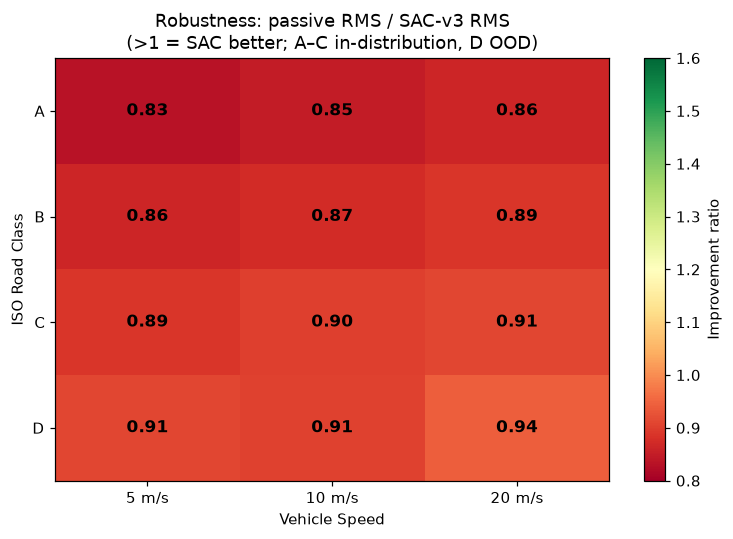

In [17]:
# Robustness sweep: ISO road classes A–D × vehicle speeds 5/10/20 m/s
road_classes = {'A': 16e-6, 'B': 64e-6, 'C': 256e-6, 'D': 1024e-6}
speeds       = [5, 10, 20]

# imp_grid: passive RMS / SAC-v3 RMS  (>1 = SAC better)
imp_grid = np.zeros((len(road_classes), len(speeds)))
t_sweep  = np.arange(int(T_SIM/DT)) * DT

for ri, (cls, Gq0) in enumerate(road_classes.items()):
    for si, v in enumerate(speeds):
        zr = iso_random_profile(t_sweep, v=v, Gq0=Gq0, seed=7)
        _, pa_sw, _  = rollout(zr, passive_policy)
        _, sa_sw, _  = eval_sac_on_road(model, zr)
        imp_grid[ri, si] = rms(pa_sw) / max(rms(sa_sw), 1e-9)

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(imp_grid, cmap='RdYlGn', vmin=0.8, vmax=1.6, aspect='auto')
ax.set_xticks(range(len(speeds)));      ax.set_xticklabels([f'{v} m/s' for v in speeds])
ax.set_yticks(range(len(road_classes))); ax.set_yticklabels(list(road_classes.keys()))
ax.set_xlabel('Vehicle Speed'); ax.set_ylabel('ISO Road Class')
ax.set_title('Robustness: passive RMS / SAC-v3 RMS\n(>1 = SAC better; A–C in-distribution, D OOD)')
plt.colorbar(im, ax=ax, label='Improvement ratio')
for ri in range(imp_grid.shape[0]):
    for si in range(imp_grid.shape[1]):
        ax.text(si, ri, f'{imp_grid[ri,si]:.2f}', ha='center', va='center',
                fontsize=11, fontweight='bold')
plt.tight_layout(); plt.show()

Wk filter peak: 6.16 Hz  (ISO 2631-1 spec: broad max 4–8 Hz)  ✓


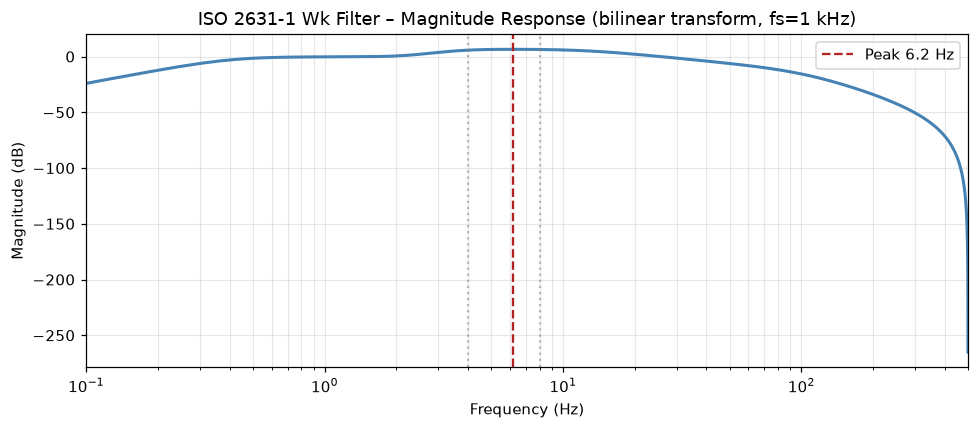


=== ISO 2631-1 Wk-Weighted RMS — ISO Class B Random Road ===
  Passive  : 0.8944 m/s²
  Skyhook  : 1.0101 m/s²  (-12.9% vs passive)
  LQR-semi : 0.7755 m/s²  (+13.3% vs passive)
  SAC-v3   : 1.0612 m/s²  (-18.6% vs passive)


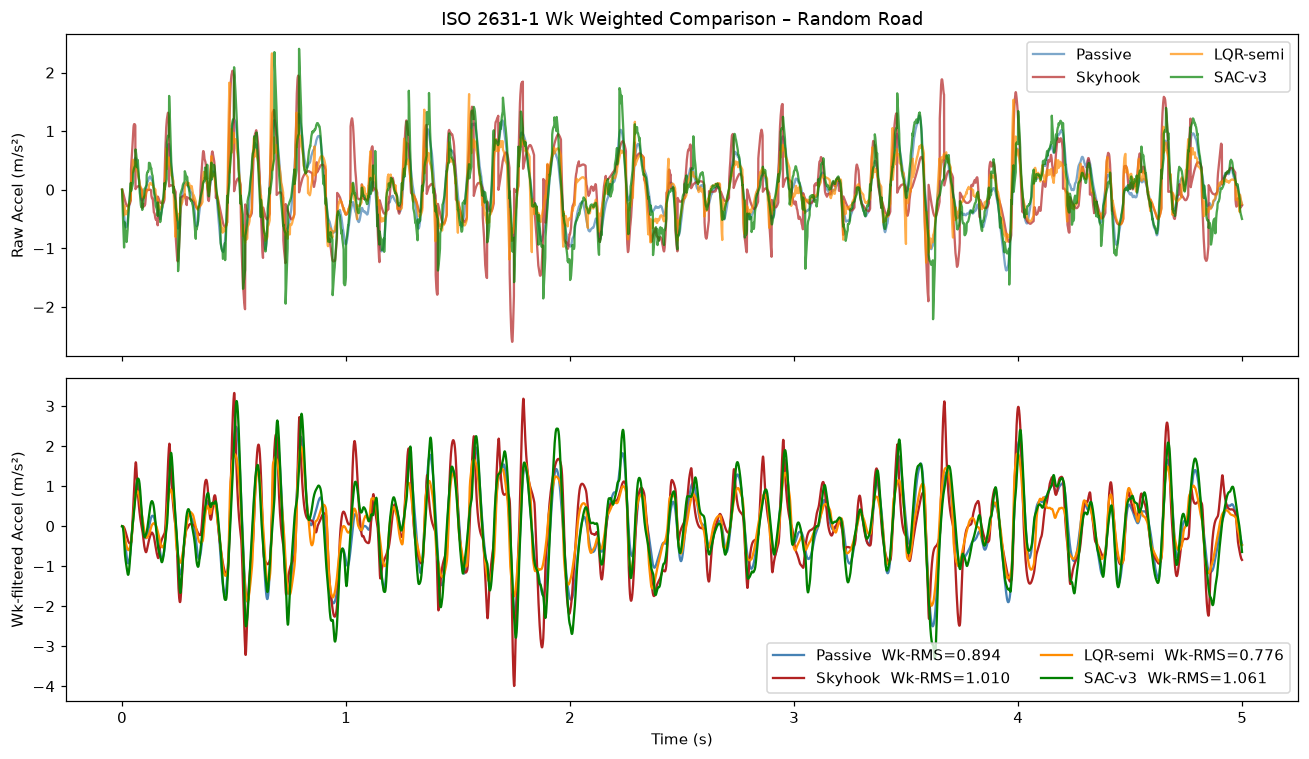

In [18]:
from scipy.signal import sosfilt, zpk2sos, sosfreqz, bilinear_zpk

def _stage(z_ct, p_ct, k_ct, fs):
    zd, pd, kd = bilinear_zpk(z_ct, p_ct, k_ct, fs)
    return zpk2sos(zd, pd, kd)

def make_wk_sos(fs=1000.):
    """
    ISO 2631-1 Wk filter: 4-stage cascade, bilinear-transformed from continuous-time spec.
      Stage 1 HP:   H(s) = s²/(s²+ω1·s/Q1+ω1²)                   f1=0.4 Hz,  Q1=1/√2
      Stage 2 LP:   H(s) = ω2²/(s²+ω2·s/Q2+ω2²)                  f2=100 Hz,  Q2=1/√2
      Stage 3 A→V: H(s) = (s+ω3)·ω4²/ω3 / (s²+ω4·s/Q4+ω4²)     f3=f4=12.5 Hz, Q4=0.63
      Stage 4 Step: H(s) = (s²+ω5·s/Q5+ω5²)/(s²+ω6·s/Q6+ω6²)·ω6²/ω5²
                                                                    f5=2.37/Q5=0.91, f6=3.35/Q6=0.91
    Magnitude should peak near 4–8 Hz (ISO 2631-1:1997 Table A.1).
    """
    stages = []
    # Stage 1 – high-pass
    f1, Q1 = 0.4, 1./np.sqrt(2); w1 = 2*np.pi*f1
    stages.append(_stage([0., 0.], np.roots([1, w1/Q1, w1**2]), 1., fs))
    # Stage 2 – low-pass
    f2, Q2 = 100., 1./np.sqrt(2); w2 = 2*np.pi*f2
    stages.append(_stage([], np.roots([1, w2/Q2, w2**2]), w2**2, fs))
    # Stage 3 – acceleration-velocity transition
    f3 = f4 = 12.5; Q4 = 0.63; w3 = 2*np.pi*f3; w4 = 2*np.pi*f4
    stages.append(_stage([-w3], np.roots([1, w4/Q4, w4**2]), w4**2/w3, fs))
    # Stage 4 – upward step
    f5, Q5, f6, Q6 = 2.37, 0.91, 3.35, 0.91
    w5 = 2*np.pi*f5; w6 = 2*np.pi*f6
    stages.append(_stage(np.roots([1, w5/Q5, w5**2]),
                          np.roots([1, w6/Q6, w6**2]), w6**2/w5**2, fs))
    return np.vstack(stages)

FS_SIM = 1. / DT   # 1000 Hz
WK_SOS = make_wk_sos(FS_SIM)

# Verify magnitude response – must peak near 4–8 Hz
w_hz, h = sosfreqz(WK_SOS, worN=8192, fs=FS_SIM)
peak_f  = w_hz[np.argmax(np.abs(h))]
assert 3. <= peak_f <= 10., f"Wk peak at {peak_f:.1f} Hz — expected 4–8 Hz range"
print(f"Wk filter peak: {peak_f:.2f} Hz  (ISO 2631-1 spec: broad max 4–8 Hz)  ✓")

fig, ax = plt.subplots(figsize=(9, 4))
ax.semilogx(w_hz[1:], 20*np.log10(np.abs(h[1:])+1e-15), color='steelblue', lw=2)
ax.axvline(peak_f, color='firebrick', ls='--', label=f'Peak {peak_f:.1f} Hz')
for f_ in [4., 8.]:
    ax.axvline(f_, color='gray', ls=':', alpha=0.5)
ax.set_xlabel('Frequency (Hz)'); ax.set_ylabel('Magnitude (dB)')
ax.set_title('ISO 2631-1 Wk Filter – Magnitude Response (bilinear transform, fs=1 kHz)')
ax.legend(); ax.set_xlim([0.1, 500]); ax.grid(True, which='both', alpha=0.3)
plt.tight_layout(); plt.show()

def wk_rms(accel):
    return rms(sosfilt(WK_SOS, accel))

print("\n=== ISO 2631-1 Wk-Weighted RMS — ISO Class B Random Road ===")
wp = wk_rms(pa_r);  ws = wk_rms(sk_r);  wl = wk_rms(lqr_r);  wsa = wk_rms(sac_r)
print(f"  Passive  : {wp:.4f} m/s²")
print(f"  Skyhook  : {ws:.4f} m/s²  ({(1-ws/wp)*100:+.1f}% vs passive)")
print(f"  LQR-semi : {wl:.4f} m/s²  ({(1-wl/wp)*100:+.1f}% vs passive)")
print(f"  SAC-v3   : {wsa:.4f} m/s²  ({(1-wsa/wp)*100:+.1f}% vs passive)")

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
for lbl, a_, c_ in [('Passive', pa_r, 'steelblue'), ('Skyhook', sk_r, 'firebrick'),
                      ('LQR-semi', lqr_r, 'darkorange'), ('SAC-v3', sac_r, 'green')]:
    axes[0].plot(t_arr, a_, color=c_, label=lbl, alpha=0.7)
    axes[1].plot(t_arr, sosfilt(WK_SOS, a_), color=c_,
                 label=f'{lbl}  Wk-RMS={wk_rms(a_):.3f}')
axes[0].set_ylabel('Raw Accel (m/s²)');        axes[0].legend(ncol=2)
axes[0].set_title('ISO 2631-1 Wk Weighted Comparison – Random Road')
axes[1].set_ylabel('Wk-filtered Accel (m/s²)'); axes[1].legend(ncol=2)
axes[1].set_xlabel('Time (s)')
plt.tight_layout(); plt.show()

---
## Active controller (out of scope — appendix only)
Cells below contain the TD3 active baseline. They are **not part of the semi-active study** and will error because `TD3`, `NormalActionNoise`, `W4_V2`, and other removed names are undefined. Do not run unless reinstating the active controller per the spec appendix.

In [19]:
class QuarterCarActiveEnv(gym.Env):
    metadata = {}
    def __init__(self, road_type='mixed', ep_len=T_SIM, dt=DT):
        super().__init__()
        self.road_type=road_type; self.ep_len=ep_len; self.dt=dt; self.n_steps=int(ep_len/dt)
        high=np.array([0.5,5.,0.5,5.,5.],dtype=np.float32)
        self.observation_space=spaces.Box(-high,high,dtype=np.float32)
        self.action_space=spaces.Box(np.array([-FA_MAX],dtype=np.float32),np.array([FA_MAX],dtype=np.float32))
        self._zr=np.zeros(self.n_steps)
        self._s_lo=np.array([-2.,-30.,-2.,-30.]); self._s_hi=np.array([2.,30.,2.,30.])
    def _obs(self):
        x1,x1d,x2,x2d=self.state; zr=self._zr[min(self.k,self.n_steps-1)]
        return np.array([x1-x2,x1d-x2d,x2-zr,x1d,x2d],dtype=np.float32)
    def reset(self,seed=None,options=None):
        super().reset(seed=seed); self.state=np.zeros(4); self.k=0
        t_fine=np.arange(0,self.ep_len,DT)
        use_bump=(self.road_type=='bump') or (self.road_type=='mixed' and self.np_random.random()<0.5)
        s=int(self.np_random.integers(0,99999)) if seed is None else seed
        zr_fine=bump_profile(t_fine) if use_bump else iso_random_profile(t_fine,seed=s)
        self._zr=np.interp(np.arange(0,self.ep_len,self.dt),t_fine,zr_fine); return self._obs(),{}
    def step(self,action):
        Fa=float(np.clip(action[0],-FA_MAX,FA_MAX)); x1,x1d,x2,x2d=self.state
        zr=self._zr[min(self.k,self.n_steps-1)]
        x1dd=(-ks*(x1-x2)-c0*(x1d-x2d)+Fa)/ms; x2dd=(ks*(x1-x2)+c0*(x1d-x2d)-kt*(x2-zr)-Fa)/mu
        x1+=x1d*self.dt; x1d+=x1dd*self.dt; x2+=x2d*self.dt; x2d+=x2dd*self.dt
        self.state=np.clip(np.array([x1,x1d,x2,x2d]),self._s_lo,self._s_hi); self.k+=1
        # NOTE: W1, W4_V2 undefined – reinstating active requires importing TD3 and defining these
        return self._obs(), 0.0, self.k>=self.n_steps, False, {}

# TD3 training not shown – requires: from stable_baselines3 import TD3
# from stable_baselines3.common.noise import NormalActionNoise
# See spec appendix for fixes needed before reinstatement.

In [20]:
W1_sweep = [0.1, 0.5, 1.0, 2.0, 5.0]

class QuarterCarEnvW1(QuarterCarEnvV2):
    def __init__(self, w1, **kw):
        super().__init__(**kw); self._w1=w1
    def step(self, action):
        c=float(np.clip(action[0],C_MIN,C_MAX)); x1,x1d,x2,x2d=self.state
        zr=self._zr[min(self.k,self.n_steps-1)]
        x1dd=(-ks*(x1-x2)-c*(x1d-x2d))/ms; x2dd=(ks*(x1-x2)+c*(x1d-x2d)-kt*(x2-zr))/mu
        x1+=x1d*self.dt; x1d+=x1dd*self.dt; x2+=x2d*self.dt; x2d+=x2dd*self.dt
        self.state=np.clip(np.array([x1,x1d,x2,x2d]),self._s_lo,self._s_hi); self.k+=1
        c_norm=(c-C_MIN)/(C_MAX-C_MIN)
        return self._obs(),float(-(self._w1*x1dd**2+W2*(x1-x2)**2+W3*(x2-zr)**2+W4_V2*c_norm**2)),self.k>=self.n_steps,False,{}

abl_accel,abl_susp=[],[]
for w1 in W1_sweep:
    env_w1=QuarterCarEnvW1(w1=w1,road_type='mixed',ep_len=T_SIM,dt=DT)
    n_abl=NormalActionNoise(mean=np.zeros(1),sigma=200.*np.ones(1))
    m_w1=TD3('MlpPolicy',env_w1,learning_rate=3e-4,buffer_size=100_000,batch_size=256,
             tau=0.005,gamma=0.999,train_freq=1,policy_delay=2,learning_starts=2000,
             action_noise=n_abl,policy_kwargs=dict(net_arch=[256,256]),device=device,verbose=0)
    m_w1.learn(total_timesteps=300_000)
    y_w1=eval_policy(m_w1,'random',zr_rand_arr,seed=42)
    abl_accel.append(rms(body_accel(y_w1))); abl_susp.append(rms(y_w1[0]-y_w1[2])*100)
    print(f"W1={w1:.1f} → accel={abl_accel[-1]:.4f}  susp={abl_susp[-1]:.4f}")

fig,ax1=plt.subplots(figsize=(9,5)); ax2=ax1.twinx()
ax1.plot(W1_sweep,abl_accel,'o-',color='steelblue',lw=2,label='Body Accel RMS')
ax2.plot(W1_sweep,abl_susp,'s--',color='darkorange',lw=2,label='Susp Travel RMS')
ax1.axhline(rms(pa_r),color='steelblue',ls=':',alpha=0.6,label='Passive accel')
ax2.axhline(rms(yp_rand[0]-yp_rand[2])*100,color='darkorange',ls=':',alpha=0.6)
ax1.set_xlabel('W1'); ax1.set_ylabel('Body Accel RMS (m/s²)',color='steelblue')
ax2.set_ylabel('Susp Travel RMS (cm)',color='darkorange')
ax1.set_title('W1 Sensitivity — TD3 (Random Road)')
l1,lb1=ax1.get_legend_handles_labels(); l2,lb2=ax2.get_legend_handles_labels()
ax1.legend(l1+l2,lb1+lb2,fontsize=8); plt.tight_layout(); plt.show()

NameError: name 'QuarterCarEnvV2' is not defined